<a href="https://colab.research.google.com/github/MilizCom/Data-mining/blob/main/Final_Dta_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load dataset
data_path = "/content/Student Depression Dataset.csv"  # Ganti dengan nama file Anda
data = pd.read_csv(data_path)


In [3]:

# Menampilkan informasi awal dataset
print("=== Informasi Dataset ===")
print(data.info())
print("\n=== Beberapa Baris Pertama Dataset ===")
print(data.head())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901

In [4]:

# 1. Preprocessing Data
# Menangani nilai kosong
data.fillna(data.median(numeric_only=True), inplace=True)


In [5]:

# Mengonversi kolom kategorikal menjadi numerik jika diperlukan
categorical_columns = ["Gender", "City", "Profession", "Dietary Habits", "Degree", "Have you ever had suicidal thoughts ?", "Family History of Mental Illness"]
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [6]:
# Menampilkan dataset setelah preprocessing
print("\n=== Dataset Setelah Preprocessing ===")
print(data.head())


=== Dataset Setelah Preprocessing ===
   id   Age  Academic Pressure  Work Pressure  CGPA  Study Satisfaction  \
0   2  33.0                5.0            0.0  8.97                 2.0   
1   8  24.0                2.0            0.0  5.90                 5.0   
2  26  31.0                3.0            0.0  7.03                 5.0   
3  30  28.0                3.0            0.0  5.59                 2.0   
4  32  25.0                4.0            0.0  8.13                 3.0   

   Job Satisfaction     Sleep Duration  Work/Study Hours  Financial Stress  \
0               0.0          5-6 hours               3.0               1.0   
1               0.0          5-6 hours               3.0               2.0   
2               0.0  Less than 5 hours               9.0               1.0   
3               0.0          7-8 hours               4.0               5.0   
4               0.0          5-6 hours               1.0               1.0   

   ...  Degree_MBBS  Degree_MCA  Degree_M

In [7]:
# Memisahkan fitur dan label
X = data.drop(columns=["Depression"])
y = data["Depression"]

In [8]:
# Membagi data menjadi train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
def convert_sleep_duration(x):
    # Handle NaN or unexpected types gracefully
    if isinstance(x, str):
        if 'hours' in x:
            if '-' in x:
                return np.mean([float(i) for i in x.split('-') if i.strip().isdigit()])  # Average the range
            elif 'Less than' in x:  # For 'Less than 5 hours'
                return 4.5
            elif 'More than' in x:  # For 'More than 8 hours'
                return 8.5
            else:
                return float(x.split()[0])  # For something like '6 hours'
    return np.nan  # Return NaN if it's not a valid string like '5-6 hours' or 'Less than 5 hours'


In [10]:
# Check which columns are still non-numeric in X_train
non_numeric_columns = X_train.select_dtypes(include=['object']).columns

# Ensure that 'Sleep Duration' is numeric
X_train['Sleep Duration'] = X_train['Sleep Duration'].apply(convert_sleep_duration)
X_test['Sleep Duration'] = X_test['Sleep Duration'].apply(convert_sleep_duration)

# Handle any other non-numeric columns by converting them to dummy variables
categorical_columns = ["Gender", "City", "Profession", "Dietary Habits", "Degree",
                       "Have you ever had suicidal thoughts ?", "Family History of Mental Illness"]

# Ensure these categorical columns exist in the data
categorical_columns = [col for col in categorical_columns if col in X_train.columns]

# Convert categorical columns to dummy variables
X_train = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)

# Now apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [12]:
from sklearn.impute import SimpleImputer

# Impute missing values with the median (this is often a good default for numeric columns)
imputer = SimpleImputer(strategy='median')

# Apply imputation to X_train and X_test (this will handle NaN values)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Now apply scaling to the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Confirm that there are no missing values
print(f"Missing values in X_train after imputation: {pd.isna(X_train_scaled).sum()}")
print(f"Missing values in X_test after imputation: {pd.isna(X_test_scaled).sum()}")

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_knn = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Model Accuracy: {knn_accuracy}")


Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0
KNN Model Accuracy: 0.7340978319297617


In [13]:

# Evaluasi KNN
y_pred_knn = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("\n=== Evaluasi Model KNN ===")
print(f"Akurasi: {knn_accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))



=== Evaluasi Model KNN ===
Akurasi: 0.7340978319297617

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      2343
           1       0.74      0.84      0.79      3238

    accuracy                           0.73      5581
   macro avg       0.73      0.71      0.72      5581
weighted avg       0.73      0.73      0.73      5581



In [14]:

# 3. Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [15]:

# Evaluasi Random Forest
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("\n=== Evaluasi Model Random Forest ===")
print(f"Akurasi: {rf_accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))



=== Evaluasi Model Random Forest ===
Akurasi: 0.8346174520695215

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2343
           1       0.85      0.87      0.86      3238

    accuracy                           0.83      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.83      0.83      0.83      5581



In [16]:

# Perbandingan Akurasi
print("\n=== Perbandingan Akurasi ===")
print(f"KNN: {knn_accuracy}")
print(f"Random Forest: {rf_accuracy}")



=== Perbandingan Akurasi ===
KNN: 0.7340978319297617
Random Forest: 0.8346174520695215


<ipython-input-18-3fee45866b40>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis")


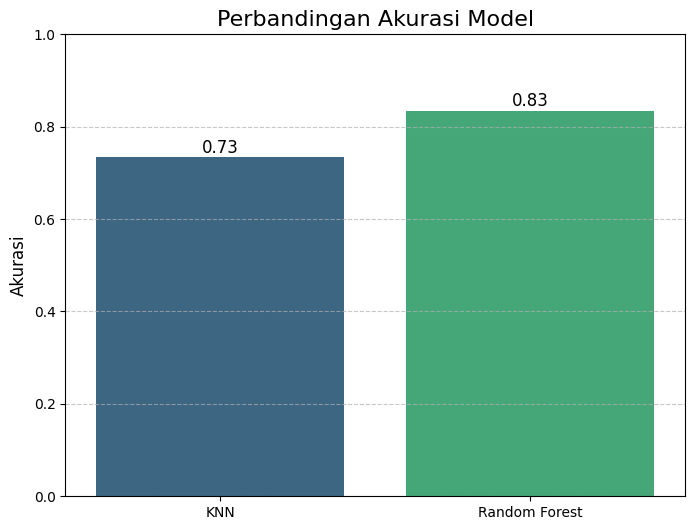

In [18]:

# 4. Visualisasi Perbandingan Akurasi
models = ["KNN", "Random Forest"]
accuracies = [knn_accuracy, rf_accuracy]

plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.title("Perbandingan Akurasi Model", fontsize=16)
plt.ylabel("Akurasi", fontsize=12)
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<ipython-input-22-103c1996fdbf>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['Depression'], y=data['Age'], palette='Set2')


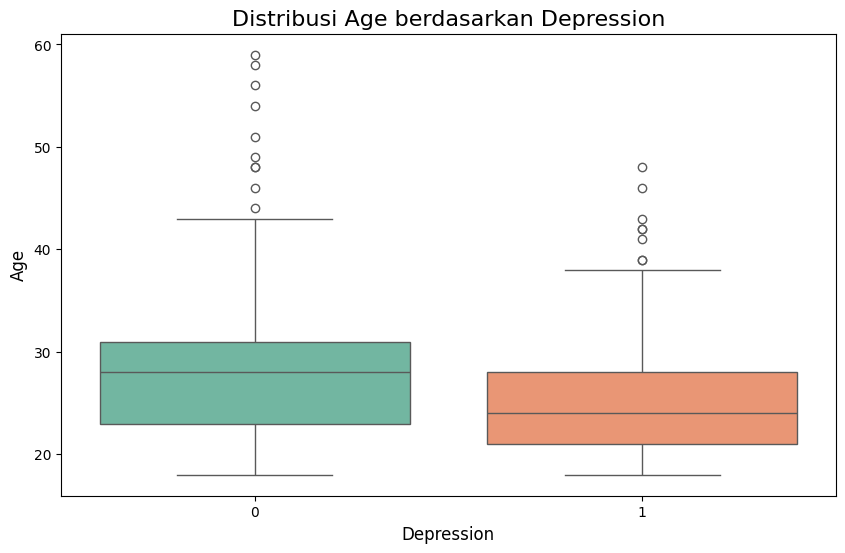

In [22]:
# Box plot untuk menganalisis distribusi 'Age' berdasarkan kategori 'Depression'
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Depression'], y=data['Age'], palette='Set2')

# Menambahkan judul dan label
plt.title('Distribusi Age berdasarkan Depression', fontsize=16)
plt.xlabel('Depression', fontsize=12)
plt.ylabel('Age', fontsize=12)

# Menampilkan plot
plt.show()


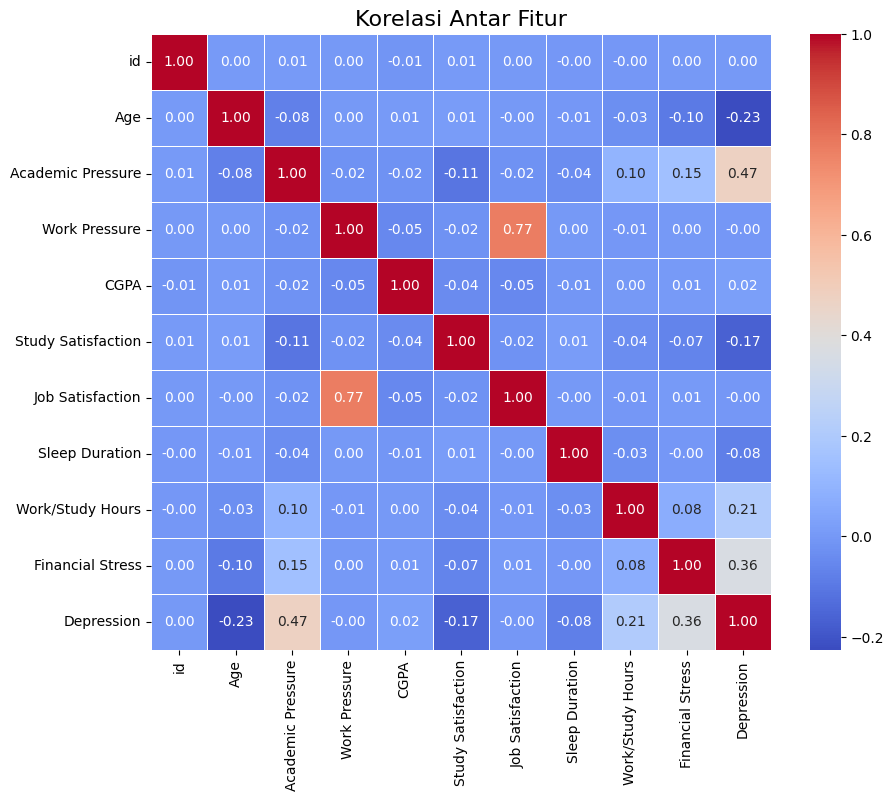

In [20]:
# First, ensure that 'Sleep Duration' is numeric
data['Sleep Duration'] = data['Sleep Duration'].apply(convert_sleep_duration)

# Now, calculate the correlation matrix, excluding non-numeric columns
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelasi Antar Fitur", fontsize=16)
plt.show()
